In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt 

In [4]:
import sklearn

In [5]:
df=pd.read_csv("/Users/Vikash/Desktop/data/moons_dataset.csv")

In [6]:
df.head()

,feature1,feature2
0,-0.021371,0.406186
1,0.976700,-0.458323
2,0.904059,-0.376520
3,0.377363,-0.397037
4,-0.841926,0.530587


In [7]:
df.shape

(1000, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   feature1  1000 non-null   float64
 1   feature2  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


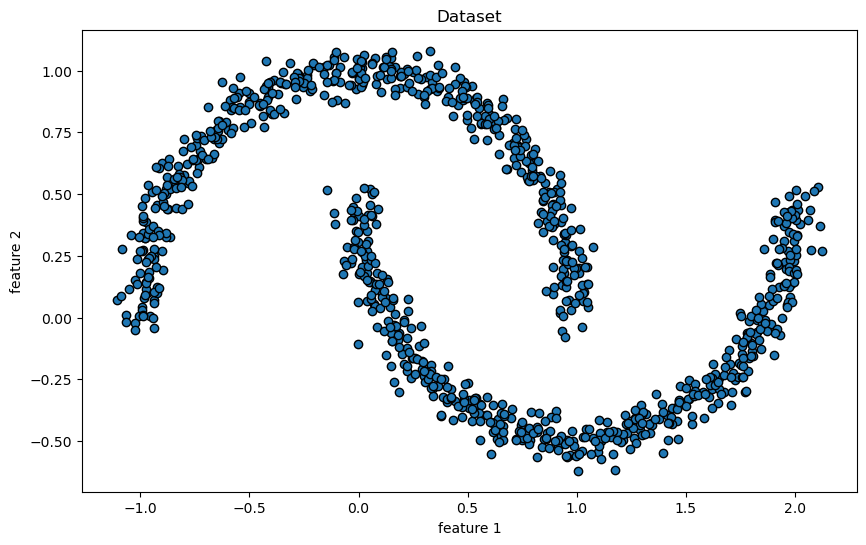

In [12]:
#create a Scaler plot
plt.figure(figsize=(10,6))
plt.scatter(df["feature1"],df["feature2"],marker="o",edgecolors="k")
plt.title("Dataset")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()


# model

In [13]:
from sklearn.cluster import KMeans


In [17]:
k_means=KMeans(n_clusters=2,random_state=42, n_init=100)


In [18]:
kmeans_label=k_means.fit_predict(df)

In [19]:
from sklearn.metrics import silhouette_score


In [20]:
kmeans_silhouette=silhouette_score(df,kmeans_label)

In [21]:
print(kmeans_silhouette)

0.4887268471194725


# Spectral clustering

In [22]:
from sklearn.cluster import SpectralClustering

In [23]:
spectral_cluter=SpectralClustering(n_clusters=2,affinity="nearest_neighbors",random_state=42)

In [24]:
sc_labels=spectral_cluter.fit_predict(df)

H:\Vikash\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [25]:
sc_silhouette=silhouette_score(df,sc_labels)
print(sc_silhouette)

0.33440074394139574


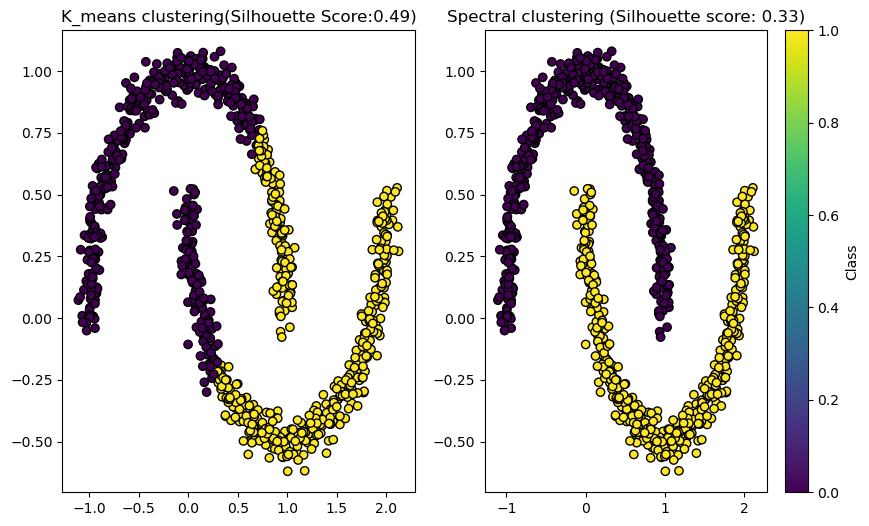

In [34]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.scatter(df["feature1"],df["feature2"],c=kmeans_label,cmap="viridis",marker="o",edgecolors="k")
plt.title(f"K_means clustering(Silhouette Score:{kmeans_silhouette:.2f})")


plt.subplot(1,2,2)
plt.scatter(df["feature1"],df["feature2"],c=sc_labels,cmap="viridis",marker="o",edgecolors="k")
plt.title(f"Spectral clustering (Silhouette score: {sc_silhouette:.2f})") 
plt.colorbar(label="Class")
plt.show()